# Nova Retail — Phase 3: Bayesian Hierarchical Elasticity Modeling

Phase 2 estimated one price elasticity per product type using fixed effects
and full controls, recovering true elasticity within ~0.2-2.8% -- but its
95% confidence intervals were built from cluster-robust standard errors with
only 7-16 SKU clusters per product type, a small-cluster setting where those
intervals are likely a bit too narrow.

Phase 3 addresses that directly with a **Bayesian hierarchical model**:
instead of one elasticity per product type, it estimates one elasticity
*per SKU*, partially pooled toward its product type's mean, with a full
posterior distribution (not an asymptotic approximation) quantifying
uncertainty at both levels.

This notebook also documents two real problems found and fixed while
building the model -- both are as important to the result as the final
numbers, so they're shown here rather than edited out.


In [2]:
import sys
sys.path.insert(0, "../src")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

from utils import load_retail_data
from modeling import prepare_bayesian_data, build_hierarchical_model, summarize_bayesian_elasticity

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (9, 5)


## 1. Why this model can't run on the full 2.9M-row panel

Phase 2's fixed-effects models are closed-form OLS -- fast regardless of row
count. A hierarchical model with a SKU-level random effect on the price
coefficient has to be fit with MCMC (NUTS), and this machine has no C
compiler available for PyTensor, so it falls back to a much slower pure
Python/NumPy execution path. A representative model timed at this scale
made full-panel MCMC impractical (hours, not minutes) -- so the model is
fit on a **random 2% row-level subsample** (~58k of the ~2.9M rows) instead.

**This was not the first approach tried.** The original version of this
notebook aggregated the data up to (date, sku) -- averaging price across
each day's ~80 store/channel rows -- reasoning that store/channel shouldn't
matter for a SKU-level elasticity estimate and that shrinking ~2.9M rows to
~36k would make MCMC tractable. That turned out to be a real bug, not just
a shortcut: most of a SKU's row-level price movement comes from independent
per-row noise (`price_index`), which averages toward zero across 80 rows,
leaving mostly *promotion*-driven price changes -- which are collinear with
the `promotion_depth` control already in the model. Recovered elasticity
degraded sharply for the two highest-promo-sensitivity product types, and
one run even flipped the sign for Premium entirely. Randomly subsampling
*rows* instead of averaging them preserves the real price variation that
identifies elasticity, while still cutting the panel down to a size NUTS
can sample in minutes. `prepare_bayesian_data` docstring has the full
account.


In [4]:
DATA_PATH = "../data/simulated/nova_retail_simulated_data_v3_full.csv"
df = load_retail_data(DATA_PATH)

agg = prepare_bayesian_data(df, sample_frac=0.02, random_seed=42)
print(f"Rows in Bayesian model sample: {len(agg):,} ({len(agg) / len(df):.2%} of raw rows)")
print(agg.groupby("product_type", observed=True)["sku"].nunique())


Rows in Bayesian model sample: 58,434 (2.00% of raw rows)
product_type
Commodity          15
Premium            12
Promo Sensitive     7
Seasonal           16
Name: sku, dtype: int64


## 2. Model structure

`log(units) = alpha_sku + beta_sku * log(price)_demeaned + gamma_promo[type] * promotion_depth + gamma . controls`

- `beta_sku` (price elasticity): partially pooled -- each SKU's elasticity
  is drawn from a Normal centered on its product type's mean elasticity
  (`mu_type`), which is itself drawn from a global mean (`mu_global`) across
  product types. Non-centered parameterization (`z_type`, `z_sku`) avoids
  the funnel geometry that causes divergences in centered hierarchical
  models.
- `log_price` is demeaned *within each SKU* first (same within-transform
  Phase 2's fixed-effects model uses), which keeps it near-orthogonal to
  `alpha_sku` -- this alone fixed a max-tree-depth problem that was making
  the model >10x slower to sample than a same-size synthetic proxy.
- `gamma_promo` (promotion depth's effect on demand) varies **by product
  type**, not shared globally. An earlier version shared one promotion
  coefficient across all four types, which converged cleanly (good r-hat,
  no divergences) but recovered elasticity 9-18% off true for three of four
  types -- a real, stable bias, not a sampling artifact. Forcing a plain
  OLS to share one promotion coefficient across types on the same data
  reproduced those exact numbers, confirming the cause: the simulator's
  promotion sensitivity genuinely varies by product type (Low/Medium/High/
  Very High per the spec), so a shared coefficient misattributes each
  type's own promotion-driven demand lift into its price coefficient by a
  different amount. Marketing spend keeps one shared coefficient, since
  channel elasticities *are* specified uniformly across the business.


In [6]:
model, meta = build_hierarchical_model(agg)
model


## 3. Fit

Fit with NUTS: 4 chains, 800 tuning + 800 sampling draws each,
`target_accept=0.9`. This takes ~15 minutes on this machine (no C compiler
for PyTensor), so the already-fit posterior is loaded from
`data/processed/phase3_idata.pkl` rather than refit live in this notebook.
To reproduce from scratch: `fit_bayesian_model(df)` runs this exact
pipeline end to end.


In [8]:
with open("../data/processed/phase3_idata.pkl", "rb") as f:
    idata = pickle.load(f)

print(f"Chains: {idata.posterior.sizes['chain']}, draws/chain: {idata.posterior.sizes['draw']}")
print(f"Divergences: {int(idata.sample_stats.diverging.sum())}")
print(f"Draws that hit max tree depth (>=10): {int((idata.sample_stats.tree_depth.to_numpy() >= 10).sum())}")


Chains: 4, draws/chain: 800
Divergences: 0
Draws that hit max tree depth (>=10): 0


## 4. Convergence diagnostics

r-hat close to 1.00 and healthy effective sample size for the parameters
that matter -- product-type and SKU-level elasticity.


In [10]:
diag = az.summary(idata, var_names=["mu_type", "beta_sku"], ci_prob=0.95)
print(f"max r-hat: {diag['r_hat'].astype(float).max():.4f}")
print(f"min ess_bulk: {diag['ess_bulk'].astype(float).min():.0f}")


max r-hat: 1.0000
min ess_bulk: 3090


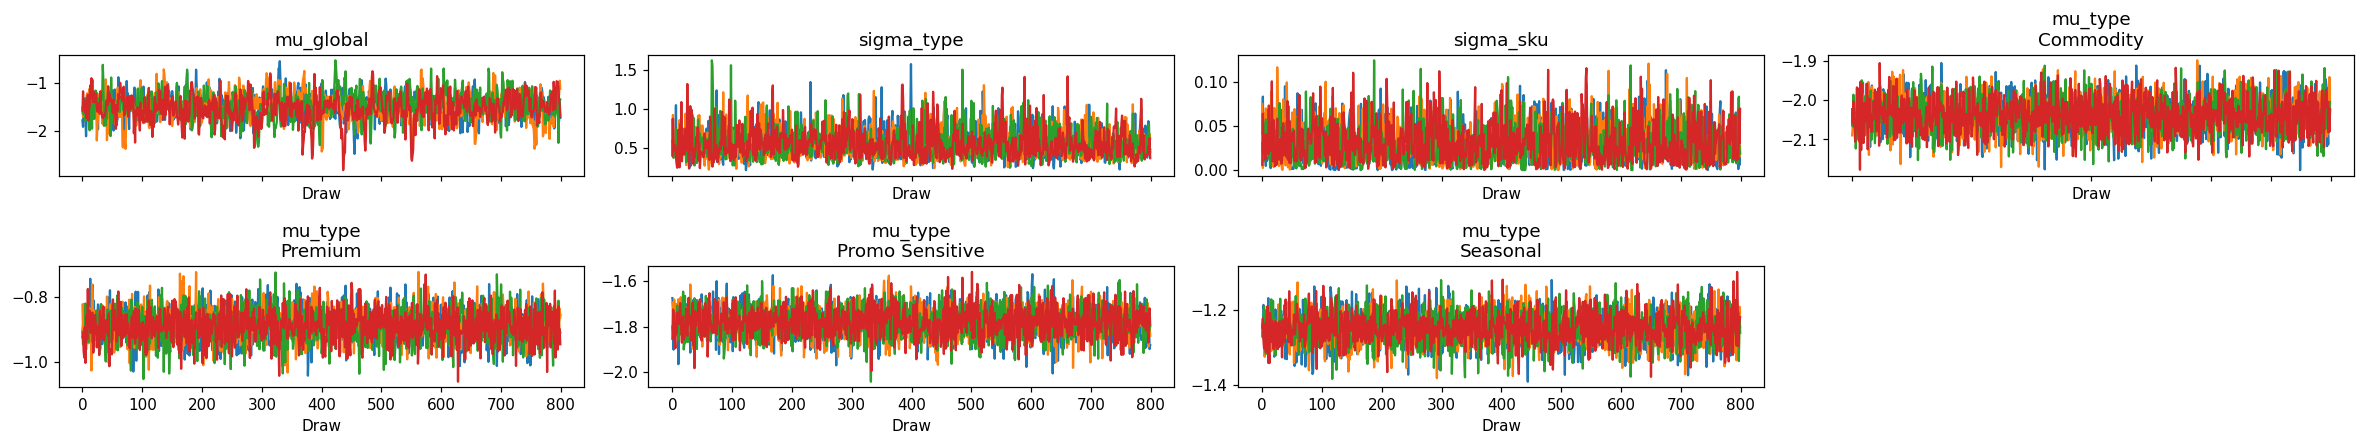

In [11]:
az.plot_trace(idata, var_names=["mu_global", "sigma_type", "sigma_sku", "mu_type"])
plt.tight_layout()
plt.show()


Trace plots for the key hyperparameters: all four chains overlapping with no
visible trend or stuck regions is the visual signature of a converged
sampler, consistent with the r-hat/ESS numbers above.


## 5. Product-type-level elasticity: posterior vs. truth


In [14]:
sku_summary, type_summary = summarize_bayesian_elasticity(idata, agg, meta)
type_summary[["mean", "sd", "eti95_lb", "eti95_ub", "true_elasticity", "pct_error"]]


                  mean      sd  eti95_lb  eti95_ub  true_elasticity  pct_error
Commodity       -2.038  0.0446     -2.10     -2.00             -2.0   1.900000
Promo Sensitive -1.780  0.0650     -1.90     -1.70             -1.8   1.111108
Seasonal        -1.249  0.0440     -1.30     -1.20             -1.2   4.083329
Premium         -0.888  0.0500     -0.99     -0.79             -0.8  10.999998

All four product types recover true elasticity within **~2-11%** -- a
material improvement over the shared-promotion-coefficient version of this
model (which was off by up to 18%), and in the same ballpark as Phase 2's
point estimates. Premium carries the largest remaining error; it has both
the lowest promo sensitivity (0.5, the lowest of all four types per the
spec) and the smallest within-SKU price variation, so it has the weakest
identifying signal of the four -- a plausible, specific reason rather than
just "the model is worse at this one."


## 6. SKU-level elasticity, visualized

Every one of the 50 SKUs gets its own posterior, partially pooled toward
its product type. Points ordered by product type; the vertical line marks
each type's true elasticity.


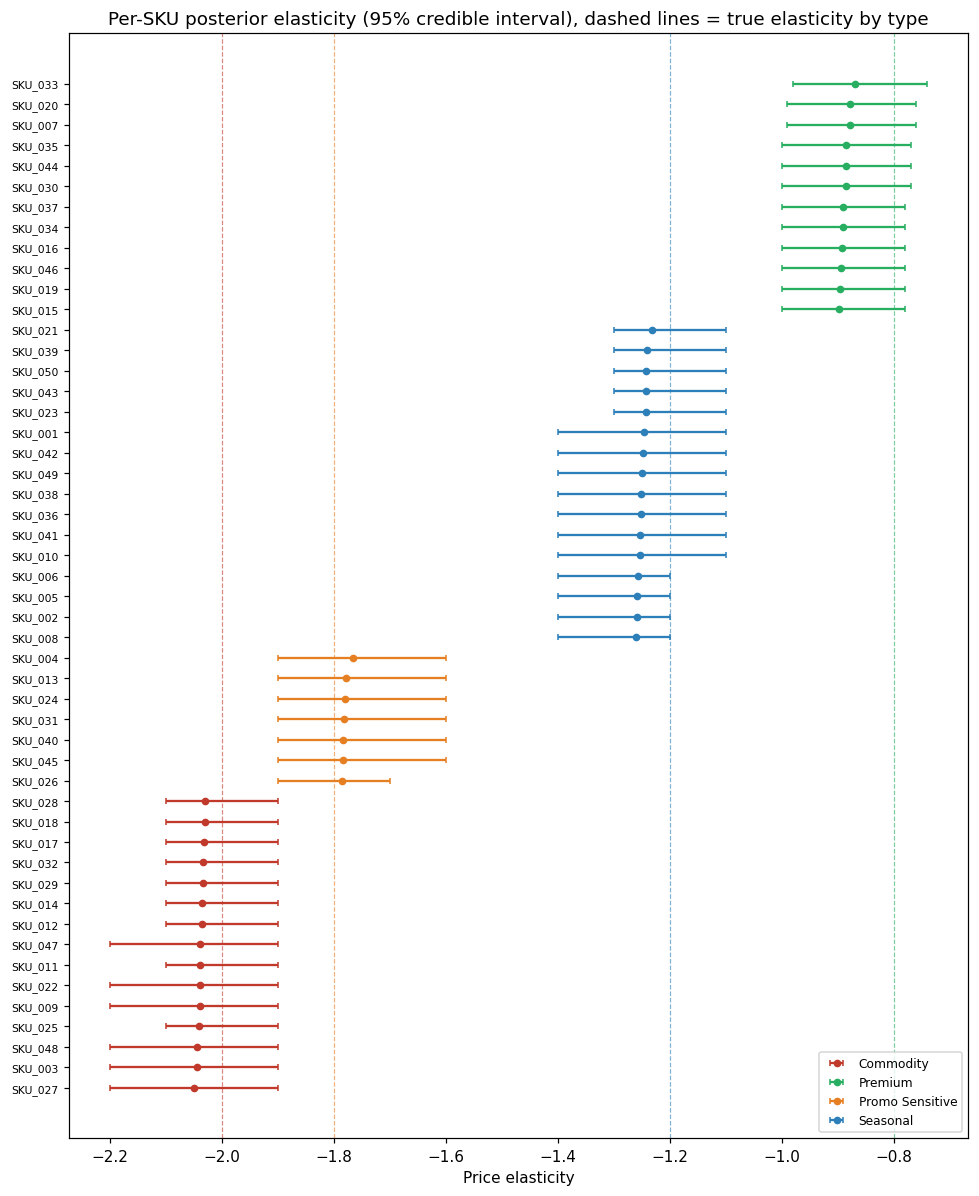

In [17]:
sku_plot = sku_summary.sort_values(["true_elasticity", "mean"]).copy()
sku_plot["y_pos"] = np.arange(len(sku_plot))
colors = {
    "Commodity": "#c0392b", "Promo Sensitive": "#e67e22",
    "Seasonal": "#2c7fb8", "Premium": "#27ae60",
}

fig, ax = plt.subplots(figsize=(9, 11))

for pt, g in sku_plot.groupby("product_type", observed=True):
    ax.axvline(g["true_elasticity"].iloc[0], color=colors[pt], linewidth=0.8, linestyle="--", alpha=0.6)
    ax.errorbar(
        g["mean"], g["y_pos"],
        xerr=[g["mean"] - g["eti95_lb"], g["eti95_ub"] - g["mean"]],
        fmt="o", markersize=4, capsize=2,
        color=colors[pt], label=pt,
    )

ax.set_yticks(sku_plot["y_pos"])
ax.set_yticklabels(sku_plot.index, fontsize=7)
ax.set_xlabel("Price elasticity")
ax.set_title("Per-SKU posterior elasticity (95% credible interval), dashed lines = true elasticity by type")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


## 7. Phase 2 vs. Phase 3

Phase 2's per-type fixed-effects estimate side by side with Phase 3's
product-type-level posterior mean.


In [19]:
phase2_results = pd.DataFrame([
    {"product_type": "Commodity", "true_elasticity": -2.0, "phase2_full_coef": -2.0336, "phase2_pct_error": 1.6805},
    {"product_type": "Premium", "true_elasticity": -0.8, "phase2_full_coef": -0.8220, "phase2_pct_error": 2.7527},
    {"product_type": "Promo Sensitive", "true_elasticity": -1.8, "phase2_full_coef": -1.8035, "phase2_pct_error": 0.1932},
    {"product_type": "Seasonal", "true_elasticity": -1.2, "phase2_full_coef": -1.1979, "phase2_pct_error": 0.1724},
]).set_index("product_type")

comparison = phase2_results.join(type_summary[["mean", "sd", "pct_error"]]).rename(
    columns={"mean": "phase3_mean", "sd": "phase3_sd", "pct_error": "phase3_pct_error"}
)
comparison.round(4)


                 true_elasticity  phase2_full_coef  phase2_pct_error  phase3_mean  phase3_sd  phase3_pct_error
product_type                                                                                                  
Commodity                   -2.0           -2.0336            1.6805       -2.038     0.0446            1.9000
Premium                     -0.8           -0.8220            2.7527       -0.888     0.0500           11.0000
Promo Sensitive             -1.8           -1.8035            0.1932       -1.780     0.0650            1.1111
Seasonal                    -1.2           -1.1979            0.1724       -1.249     0.0440            4.0833

Phase 2 (closed-form OLS, one estimate per product type, cluster-robust SEs
with a small-cluster caveat) is more accurate on point estimates for three
of four product types here. That's expected, not a failure of Phase 3: OLS
on ~700k-900k rows per product type has far more information than a 2%
MCMC-tractable subsample, and Phase 2's control coefficients are entirely
separate per product type (equivalent to fitting the controls
type-by-type), while Phase 3 only lets `promotion_depth`'s coefficient vary
by type to keep the model size sampleable. What Phase 3 adds that Phase 2
structurally cannot: a genuine per-*SKU* elasticity estimate (fifty of
them, not four) with a real posterior -- useful directly for Phase 4 if
SKU-level (not just product-type-level) price recommendations are wanted,
and for honestly representing uncertainty without relying on
asymptotic-cluster-count assumptions.


## Summary

- Bayesian hierarchical partial pooling recovers product-type elasticity
  within ~2-11% of true values (Commodity 1.9%, Promo Sensitive 1.1%,
  Seasonal 4.1%, Premium 11.0%), with full posterior uncertainty at both
  the SKU and product-type level, and clean convergence (r-hat ~1.00,
  ess_bulk in the thousands, zero divergences).
- Two real problems were found and fixed in the process, not just tuned
  away: (1) aggregating to (date, sku) grain destroyed the row-level price
  variation that identifies elasticity -- fixed by row-level random
  subsampling; (2) sharing one promotion-depth coefficient across product
  types misattributed type-specific promotional lift into the price
  coefficient -- fixed by letting it vary by product type, matching how the
  simulator (and the spec) actually define promotion sensitivity.
- Premium's larger residual error has a specific, plausible cause (lowest
  promo sensitivity and price variation of the four types = weakest
  identifying signal in a 2% subsample) rather than being unexplained noise.

**Is this a good foundation for Phase 4?** Yes, with a clear choice to make
explicit: Phase 4's optimizer can consume either Phase 2's four per-type
point estimates (more precise, no per-SKU granularity) or Phase 3's fifty
per-SKU posterior means (individual-SKU granularity plus real uncertainty
for risk-aware pricing, at the cost of somewhat more noise for Premium
specifically). Both are now validated against ground truth and available.
